In [1]:
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(ggplot2))


In [2]:
THEME=theme_classic()
CUTOFF=100
#data.table version

#tidyversion
allreadsdir<-function(dirpath){
    allreads<-tibble()
    C=0
    for (i in list.files(path = dirpath,pattern = "CBC.csv",full.names = TRUE)){
        C=C+1
        print(i)
        label=strsplit(strsplit(i,dirpath)[[1]][2],split = "_S")[[1]][1]
        print(label)
        SAM=fread(i)
        SAM=readr::read_delim(i,num_threads = 8)
        SAM$sample=i
        SAM$datalabel=label
        SAM=SAM %>% group_by(CBC) %>% mutate(UMIcount=length(unique(UMI)))
        SAM=SAM %>% group_by(flag) %>% mutate(strand=ifelse(flag==16,"Positive","Negative"))
        #SAM<-merge(SAM,BC,by.x = "CBC",by.y = "Barcode")
        counts=SAM %>% spread(UMI,UMI)        
        allreads=dplyr::bind_rows(allreads,counts)
        SAM=NULL
    }
    return(allreads)
    }

In [ ]:
EV71=fread("/hpcdata/lvd_qve/Lab_Spaces/PTD/notebooks/EVA71_TT_S4_CBC_SCISSORS.csv")    
#readr::write_rds(EV71,file = "EV71_SCISSORS.rds")
EV71

In [4]:
CVB=allreadsdir("/hpcdata/lvd_qve/Projects/PTD_StrandSpecificCounting_scRNAseq/81123_SCISSORS_FreshAnalysis/CVB/")    

In [109]:
CollectFiles<-function(files){
    allfiles=NULL
    for (i in files){
        IF=fread(i)
        IF$filename=i
        allfiles=rbindlist(list(allfiles,IF))
        }
    return(allfiles)
    }

In [110]:
FList=c("Mock_5h_S5_CBC_SCISSORS.csv",
#"CVB3_HH_S1_CBC_SCISSORS.csv",
"CVB3_TT_S2_CBC_SCISSORS.csv",
#"EVA71_HH_S3_CBC_SCISSORS.csv",
"EVA71_TT_S4_CBC_SCISSORS.csv")

In [ ]:
FirstSet=CollectFiles(FList)

Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Transformation introduced infinite values in continuous y-axis”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 29 rows containing non-finite values (`stat_smooth()`).”
Warning message in `[.data.table`(FirstSet, , , by = datalabel):
“Ignoring by= because j= is not supplied”
Warning message in `[.data.table`(FirstSet, , , by = datalabel):
“i and j are both missing so ignoring the other arguments. This warning will be upgraded to error in future.”


V1,CBC,det_strand,sample,datalabel,CBC_count,UMI_count,det_strand_count,Neg,Pos,Neg_PosRatio,Rep_Index,filename
<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
1,CAAGGCCCATGGAATA,Pos,Mock_5h_S5_CBC.csv,Mock_5h,349,2,2,106,419,2.523810e-01,2.019048e-01,Mock_5h_S5_CBC_SCISSORS.csv
2,CAAGGCCCATGGAATA,Pos,Mock_5h_S5_CBC.csv,Mock_5h,349,1,1,106,419,2.523810e-01,2.019048e-01,Mock_5h_S5_CBC_SCISSORS.csv
3,CAAGGCCCATGGAATA,Neg,Mock_5h_S5_CBC.csv,Mock_5h,349,1,1,106,419,2.523810e-01,2.019048e-01,Mock_5h_S5_CBC_SCISSORS.csv
13,CAAGGCCCATGGAATA,Pos,Mock_5h_S5_CBC.csv,Mock_5h,349,3,3,106,419,2.523810e-01,2.019048e-01,Mock_5h_S5_CBC_SCISSORS.csv
56,CAAGGCCCATGGAATA,Pos,Mock_5h_S5_CBC.csv,Mock_5h,349,4,4,106,419,2.523810e-01,2.019048e-01,Mock_5h_S5_CBC_SCISSORS.csv
73,CAAGGCCCATGGAATA,Neg,Mock_5h_S5_CBC.csv,Mock_5h,349,3,3,106,419,2.523810e-01,2.019048e-01,Mock_5h_S5_CBC_SCISSORS.csv
108,CAAGGCCCATGGAATA,Neg,Mock_5h_S5_CBC.csv,Mock_5h,349,2,2,106,419,2.523810e-01,2.019048e-01,Mock_5h_S5_CBC_SCISSORS.csv
0,GACGTTATCTTATCTG,Neg,CVB3_TT_S2_CBC.csv,CVB3_TT,2253,1,1,1041,2428,4.285714e-01,3.000865e-01,CVB3_TT_S2_CBC_SCISSORS.csv
4,GTGCAGCGTAGATTAG,Neg,CVB3_TT_S2_CBC.csv,CVB3_TT,2601,1,1,548,3485,1.572002e-01,1.358790e-01,CVB3_TT_S2_CBC_SCISSORS.csv


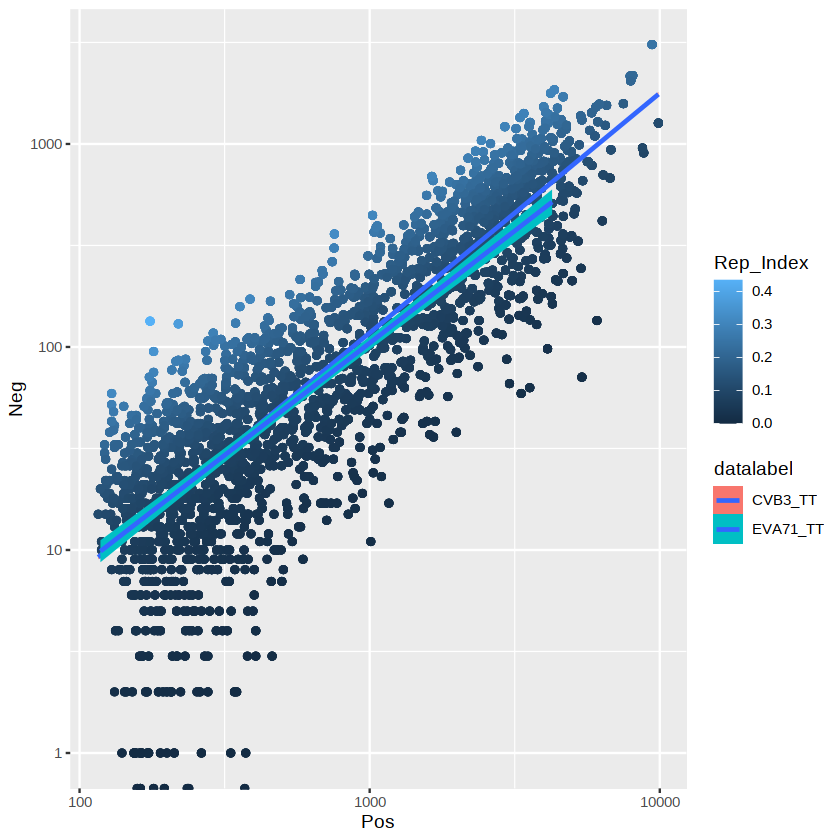

In [98]:
ggplot(FirstSet[(Neg<10000)&(Pos<10000)])+
geom_point(aes(Pos,Neg,col=Rep_Index))+
geom_smooth(method = 'lm',aes(Pos,Neg,fill=datalabel),alpha=1)+
scale_x_log10()+
scale_y_log10()

FirstSet[,,by=datalabel]


In [ ]:
PV=allreadsdir("/hpcdata/lvd_qve/Projects/PTD_StrandSpecificCounting_scRNAseq/81123_SCISSORS_FreshAnalysis/PV_Rep")    
readr::write_rds(PV,file = "PV_SCISSORS.rds")

In [ ]:
singles=unique(PV$datalabel)[c(11,3,4,5,6)]
doubles=unique(PV$datalabel)[c(7,8,9,10)]
IRES=unique(PV$datalabel)[c(11,13,1,2,6,12,14,15)]

singles
doubles
IRES

In [ ]:
computeRepIndex=function(allreads,valuevar){
    DTsam=dcast.data.table(allreads,CBC+sample+datalabel~strand,value.var = valuevar,fill=0)
    DTsam[,readSum:=Negative+Positive]
    DTsam[,repIndex:=Negative/readSum]
    print(DTsam[,sum(na.omit(Negative))/(sum(na.omit(Positive))+sum(na.omit(Negative)))])
    DTsam[,DataTable:=valuevar]
    return(DTsam)
}

In [ ]:
CVBDT=computeRepIndex(CVB,"CVB3_RNA")
EV71DT=computeRepIndex(EV71,"pUC19-EV71-TW_Tainan_1998_4643_BsmBI-and-BsaI-free-Deleted")
PVrep=computeRepIndex(PV,"RepliconNoInsert")
PVgfp=computeRepIndex(PV,"eGFP")
PVruby=computeRepIndex(PV,"mRuby3")


In [ ]:
PVgfp[,c("meanRI","sdRI"):=list(mean(na.omit(repIndex)),sd(na.omit(repIndex))),by=datalabel]

In [ ]:
ggplot(PVgfp)+
    geom_point(aes(readSum,repIndex),alpha=ifelse(PVgfp$readSum>CUTOFF,0.4,0.02))+THEME

In [ ]:
ggplot(EV71DT[readSum>CUTOFF])+
    geom_point(aes(log10(Negative/(1+Positive)),log10(repIndex)))+THEME

In [ ]:
virus<-rbindlist(list(CVBDT,EV71DT))
allDTs<-rbindlist(list(PVrep,PVgfp,PVruby))[DataTable!="RepliconNoInsert"]

`geom_smooth()` using formula = 'y ~ x'


[1] 232.112899   6.009664

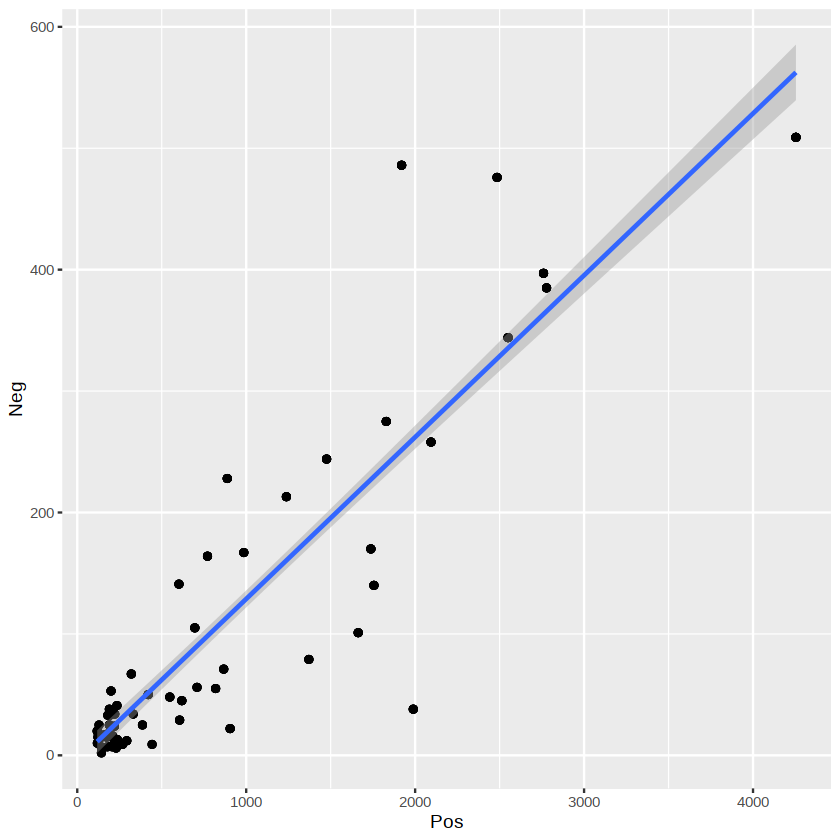

In [42]:
virus=EV71[EV71$Neg<10000]

ggplot(virus)+
    geom_point(aes(Pos,Neg))+
    geom_smooth(method = "lm",aes(Pos,Neg))

summary(with(virus,lm(Pos~Neg)))$coef[1:2]

In [26]:


viosV<-ggplot(virus)+THEME+ylab("Replication Index")+xlab("Virus")+
    geom_violin(aes(fill=DataTable,datalabel,repIndex))+
    geom_boxplot(alpha=0.4,width=0.2,aes(datalabel,repIndex))+
    scale_fill_brewer("Virus",palette = "Dark2")+
    theme(axis.text.x = element_text(hjust=1,angle=90))

viosPV<-ggplot(allDTs[readSum>CUTOFF&datalabel%in%c(singles,doubles)])+scale_y_log10()+THEME+ylab("Replication Index")+xlab("Replicon")+
    geom_violin(aes(fill=DataTable,paste(factor(datalabel,levels = c('/WT_GFP','/RFPMutPol','/WT_GFP_RFPMutPol','/RFP_488P','/WT_GFP_RFP_488P','/RFP_C109S','/WT_GFP_RFP_C109S','/RFP_D177A','/WT_GFP_RFP_D177A')),DataTable),repIndex))+
    geom_boxplot(alpha=0.4,width=0.2,aes(fill=DataTable,paste(factor(datalabel,levels = c('/WT_GFP','/RFPMutPol','/WT_GFP_RFPMutPol','/RFP_488P','/WT_GFP_RFP_488P','/RFP_C109S','/WT_GFP_RFP_C109S','/RFP_D177A','/WT_GFP_RFP_D177A')),DataTable),repIndex))+
    scale_fill_brewer("Replicon",palette = "Set1")+
    theme(axis.text.x = element_text(hjust = 1,angle=90))

viosPVsingle<-ggplot(allDTs[readSum>CUTOFF&datalabel%in%singles])+scale_y_log10()+THEME+ylab("Replication Index")+xlab("Replicon")+
    geom_violin(aes(fill=datalabel,reorder(datalabel,repIndex,max),repIndex))+
    geom_boxplot(alpha=0.4,width=0.2,aes(datalabel,repIndex))+
    scale_fill_brewer("Replicon",palette = "Set1")+
                 facet_wrap(~DataTable)+theme(axis.text.x = element_text(hjust = 1,angle=90))

viosPVdouble<-ggplot(allDTs[readSum>CUTOFF&datalabel%in%doubles])+scale_y_log10()+THEME+ylab("Replication Index")+xlab("Replicon")+
    geom_violin(aes(fill=datalabel,reorder(datalabel,repIndex,max),repIndex))+
    geom_boxplot(alpha=0.4,width=0.2,aes(datalabel,repIndex))+
    scale_fill_brewer("Replicon",palette = "Dark2")+
                 facet_wrap(~DataTable)+theme(axis.text.x = element_text(hjust = 1,angle=90))

viosPVires<-ggplot(allDTs[readSum>CUTOFF&datalabel%in%IRES])+scale_y_log10()+THEME+ylab("Replication Index")+xlab("Replicon")+
    geom_violin(aes(fill=factor(datalabel,levels=c('/WT_IRES_GFP','/WT_GFP','/RFPMutPol','/WT_IRES_mRuby3_MutPol','/Del_IRES_mRuby3','/WT_IRES_mRuby3_MutPol_WT_IRES_GFP','/Del_IRES_mRuby3_MutPol','/WT_IRES_GFP_Del_IRES_mRuby3')),factor(datalabel,levels=c('/WT_IRES_GFP','/WT_GFP','/RFPMutPol','/WT_IRES_mRuby3_MutPol','/Del_IRES_mRuby3','/WT_IRES_mRuby3_MutPol_WT_IRES_GFP','/Del_IRES_mRuby3_MutPol','/WT_IRES_GFP_Del_IRES_mRuby3')),repIndex))+
    geom_boxplot(alpha=0.4,width=0.2,aes(datalabel,repIndex))+
    scale_fill_brewer("Replicon",palette = "Paired")+
                 facet_wrap(~DataTable)+theme(axis.text.x = element_text(hjust = 1,angle=90))


ERROR: Error in eval(expr, envir, enclos): object 'allDTs' not found


In [ ]:

ggsave(filename = "vios_V.pdf",viosV,width=8,height=6)
ggsave(filename = "vios_PV.pdf",viosPV,width=9,height=6)
ggsave(filename = "vios_Vsingles.pdf",viosPVsingle,width=6,height=6)
ggsave(filename = "vios_Vdoubles.pdf",viosPVdouble,width=8,height=6)
ggsave(filename = "vios_PVires.pdf",viosPVires,width=8,height=6)


In [ ]:
merge_GR<-merge.data.table(fill=0,PVgfp[readSum>CUTOFF],PVruby[readSum>CUTOFF],all = T,by = c("CBC","sample","datalabel"),suffixes = c("G","R"))
merge_GR[is.na(merge_GR)]<-0

In [ ]:
ggplot(merge_GR[(readSumG>CUTOFF)|(readSumR>CUTOFF)&(datalabel%in%doubles)],aes(repIndexG,repIndexR,col=datalabel))+
    geom_point()+#scale_x_log10()+scale_y_log10()+
    geom_smooth(method = 'lm')+THEME+coord_fixed()#+facet_grid(~datalabel)
ggplot(merge_GR[(readSumG>CUTOFF)|(readSumR>CUTOFF)&(datalabel%in%doubles)],aes(repIndexG,repIndexR,col=datalabel))+
    geom_point()+
    geom_smooth(method = 'gam')+THEME+coord_fixed()#+facet_grid(~datalabel)

In [ ]:
bincounts<-merge_GR[,as.data.table(table(ifelse(repIndexR>0.035,"R+","R-"),ifelse(repIndexG>0.035,"G+","G-"))),by=c("datalabel")]

bincounts[,normCellN:=(N/sum(N)),by=datalabel]
unique(bincounts$datalabel)

IRESsamples=c('/WT_IRES_GFP',
'/RFPMutPol',
'/WT_IRES_mRuby3_MutPol',
'/WT_IRES_mRuby3_MutPol_WT_IRES_GFP',
'/Del_IRES_mRuby3',
'/WT_IRES_GFP_Del_IRES_mRuby3',
'/Del_IRES_mRuby3_MutPol')

mutSamples=c('/WT_GFP',
  '/RFPMutPol',
  '/WT_GFP_RFPMutPol',
'/RFP_488P',
'/WT_GFP_RFP_488P',
'/RFP_C109S',
'/WT_GFP_RFP_C109S',
 '/RFP_D177A',
'/WT_GFP_RFP_D177A')

library(cowplot)
cowplot::plot_grid(nrow = 2,align = "hv",
    ggplot(bincounts[datalabel%in%IRESsamples])+ggtitle("IRES")+xlab("Infected Cell Bin")+ylab("Condition")+
    geom_point(aes(paste(V1,V2),factor(datalabel,levels = IRESsamples),col=paste(V1,V2),size=normCellN))+scale_color_manual("Cell Bin",values = c("grey","darkgreen","darkred","goldenrod"))+THEME,

    ggplot(bincounts[datalabel%in%mutSamples])+ggtitle("Mutants")+xlab("Infected Cell Bin")+ylab("Condition")+
    geom_point(aes(paste(V1,V2),factor(datalabel,levels = mutSamples),col=paste(V1,V2),size=normCellN))+scale_color_manual("Cell Bin",values = c("grey","darkgreen","darkred","goldenrod"))+THEME
)
ggplot(bincounts)+ggtitle("Counts")+
geom_point(aes(paste(V1,V2),datalabel,col=paste(V1,V2),size=N))+scale_color_manual("Cell Bin",values = c("grey","darkgreen","darkred","goldenrod"))+THEME

In [ ]:
ggplot(merge_GR[datalabel%in%doubles],aes(repIndexG,repIndexR,col=datalabel))+
    geom_point()+
    geom_smooth(method = 'lm')+THEME
ggplot(merge_GR[datalabel%in%doubles],aes(repIndexG,repIndexR,col=datalabel))+
    geom_point()+
    geom_smooth(method = 'gam')+THEME


ggplot(merge_GR[datalabel%in%doubles],aes(NegativeG,PositiveG,col=datalabel))+
    geom_point()+
    geom_smooth(method = 'glm')+THEME

In [ ]:
dAR[,negpos:=(Negative+1)/(Positive+1)]
ARF<-melt(dAR,id.vars = c("CBC","sample","datalabel","region","negpos"))
allreadsre<-dcast.data.table(ARF,CBC+datalabel+negpos+variable~region)
#print(allreadsre)
allreadsre[,mRuby3:=ifelse(is.na(mRuby3),0,mRuby3),by=CBC]
allreadsre[,eGFP:=ifelse(is.na(eGFP),0,eGFP),by=CBC]
allreadsre[,RepliconNoInsert:=ifelse(is.na(RepliconNoInsert),0,RepliconNoInsert),by=CBC]

In [ ]:
ggsave( "count_histogram.pdf",width = 4,height=10,
    ggplot(allreadsre)+
    geom_histogram(aes(eGFP+1),fill="darkgreen",alpha=.4)+
    geom_histogram(aes(mRuby3+1),fill="darkred",alpha=.4)+
    facet_grid(datalabel~variable,scales = "free_y")+
    scale_x_log10(limits=c(2,NA))
)


ggplot(allreadsre)+
geom_histogram(aes(eGFP+1),fill="darkgreen",alpha=.4)+
geom_histogram(aes(mRuby3+1),fill="darkred",alpha=.4)+
facet_grid(variable~datalabel,scales = "free_y")+
scale_x_log10(limits=c(2,NA))

In [ ]:
ggplot(allreadsre[])+
geom_point(aes(eGFP,log10(negpos)),col="darkgreen")+
geom_point(aes(mRuby3,log10(negpos)),col="darkred")+
facet_grid(datalabel~variable)+
coord_cartesian(xlim=c(0,1000))+
xlab("read counts")

In [ ]:
ggplot(allreadsre[(eGFP>1)|(mRuby3>1)])+
geom_violin(aes(log10(eGFP+1),datalabel),col="darkgreen")+
geom_violin(aes(log10(mRuby3+1),datalabel),col="darkred")+
geom_boxplot(aes(log10(eGFP+1),datalabel),col="darkgreen")+
geom_boxplot(aes(log10(mRuby3+1),datalabel),col="darkred")+
facet_grid(variable~eGFP>10)

In [ ]:
dAR[CBC%in%dAR[(Positive>10)&(region!='RepliconNoInsert'),nrow(.SD),by=list(sample,CBC)][V1==2,]$CBC]

In [ ]:
dAR

In [ ]:
filtered<-dAR[datalabel=="WT_IRES_GFP"&region=="eGFP"]

dAR[Negative>10,paste(round(median(negpos), digits=2),"+/-",round(mad(negpos),digits = 2)),by=c("datalabel","region"),][region%in%c("eGFP","mRuby3")]

medians=dAR[Negative>10,list(median=round(median(negpos), digits=2),lowerq=round(sort(negpos)[0.25*length(negpos)],digits = 2),upperq=round(sort(negpos)[0.75*length(negpos)],digits = 2)),by=c("datalabel","region"),][region%in%c("eGFP","mRuby3")]
pdf("pointrange_replicationRate_Scissors.pdf")
ggplot(medians[-9])+
    scale_color_manual("Reporter",values = c("darkgreen","darkred"))+
    geom_pointrange(aes(factor(datalabel,levels = c("WT_IRES_GFP","Del_IRES_mRuby3","WT_IRES_mRuby3_MutPol","Del_IRES_mRuby3_MutPol","WT_IRES_GFP_Del_IRES_mRuby3","WT_IRES_mRuby3_MutPol_WT_IRES_GFP")),y=median,ymax=upperq, ymin=lowerq,col=region), lwd=1)+
    theme(axis.text.x = element_text(angle=90))+ylab("Negative:Postive RNA Ratio\nReplication Rate")+xlab("Transfected Replicon Construct")
dev.off()



In [ ]:
dAR[region%in%c("mRuby3","eGFP"),]#ggplot()+geom_point(aes(Negative,Positive))+scale_x_log10()+scale_y_log10()

In [ ]:
#ggplot(dAR)+
#    geom_point(aes(region,negpos))+
#    geom_segment(aes(x=region,xend=region,y=negpos,yend=negpos))


FILT=dAR[Positive>10&region%in%c("mRuby3","eGFP")]

ResFILT<-dcast.data.table(FILT,CBC+datalabel~region)
ResFILT
ggplot(ResFILT[datalabel%in%c("WT_IRES_mRuby3_MutPol_WT_IRES_GFP","WT_IRES_GFP_Del_IRES_mRuby3"),])+
geom_point(aes(eGFP,mRuby3,col=datalabel))+
geom_smooth(method = "lm",aes(eGFP,mRuby3,col=datalabel))


In [ ]:
DATA<-fread("./lab_share/Projects/PTD_StrandSpecificCounting_scRNAseq/CellRanger/WT_IRES_GFP/outs/analysis/umap/gene_expression_2_components/projection.csv")
DATA

DATA[,CBC:=strsplit(Barcode,split = "-")[[1]][1],by=Barcode]
DATAm<-merge.data.table(DATA,filtered,by="CBC")
ggplot(DATAm)+
geom_point(data=DATA,aes(`UMAP-1`,`UMAP-2`),cex=0.3)+
geom_point(aes(`UMAP-1`,`UMAP-2`,color=-log10(negpos)))+coord_fixed()+scale_color_viridis_c(direction = 1)


In [ ]:
DATA<-fread("./lab_share/Projects/PTD_StrandSpecificCounting_scRNAseq/CellRanger/WT_IRES_GFP/outs/analysis/tsne/gene_expression_2_components//projection.csv")
DATA[,CBC:=strsplit(Barcode,split = "-")[[1]][1],by=Barcode]
DATAm<-merge.data.table(DATA,filtered,by="CBC")
pdf("TSNE.pdf",width = 10,height=10)
ggplot(DATAm)+
geom_point(data=DATA,aes(`TSNE-1`,`TSNE-2`),cex=0.3)+
geom_point(aes(`TSNE-1`,`TSNE-2`,color=log10(negpos),size = Positive))+
scale_size_continuous("Viral Genome Count")+
coord_fixed()+
scale_color_viridis_c(direction = 1,"log10((-) to (+) Ratio)\n(Replication Rate)")
dev.off()

In [43]:
ggplot(DATAm)+
geom_point(data=DATA,aes(`TSNE-1`,`TSNE-2`),cex=0.3)+
geom_point(aes(`TSNE-1`,`TSNE-2`,color=log10(negpos),size = Positive))+
scale_size_continuous("Viral Genome Count")+
coord_fixed()+
scale_color_viridis_c(direction = 1,"log10((-) to (+) Ratio)\n(Replication Rate)")

ERROR: Error in eval(expr, envir, enclos): object 'DATAm' not found
